# Analise das metricas de prompt optimization do user_knn

Este notebook percorre os diretorios `mmr_lambda_*` dentro de `out/prompt_optimization/Llama3.1-I/user_knn`, procura os arquivos `optimization_process_metadata.json` e plota a evolucao das metricas por epoca para os experimentos do algoritmo `user_knn`.

Ele tambem incorpora os resultados de teste salvos em `out/test_explainability`, mostrando:
- o teste `without_optimization`, exibido uma unica vez;
- e os testes `with_optimization` correspondentes a cada configuracao do `user_knn`.

Observacoes:
- O eixo x representa a epoca.
- O eixo y representa o valor da metrica.
- Quando disponivel, o notebook plota as curvas de treino (`train_metric`) e validacao (`val_metric`).
- Para cada grafico, o notebook tambem exibe uma tabela pandas com os valores por epoca.
- Diretorios sem `optimization_process_metadata.json` sao reportados em tela.


In [1]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

SAVE_FIGURES = False

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "run_prompt_optimizer.py").exists() and (candidate / "out").exists():
            return candidate
    raise FileNotFoundError(
        "Nao foi possivel localizar a raiz de explainability-with-LLMs. "
        "Execute o notebook a partir do projeto ou de um subdiretorio dele."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ALGORITHM_NAME = "user_knn"
DATA_DIR = PROJECT_ROOT / "out" / "prompt_optimization" / "Llama3.1-I" / ALGORITHM_NAME
ANALYSIS_DIR = DATA_DIR / "analysis"
FIGURES_DIR = ANALYSIS_DIR / "figures"
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TEST_ROOT = PROJECT_ROOT / "out" / "test_explainability"
DEFAULT_TEST_METADATA_PATH = TEST_ROOT / "without_optimization" / "Llama3.1-I" / ALGORITHM_NAME / "sep" / "responses_metadata.json"
TEST_WITH_OPT_DIR = TEST_ROOT / "with_optimization" / "Llama3.1-I" / ALGORITHM_NAME

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ALGORITHM_NAME: {ALGORITHM_NAME}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"DEFAULT_TEST_METADATA_PATH: {DEFAULT_TEST_METADATA_PATH}")
print(f"TEST_WITH_OPT_DIR: {TEST_WITH_OPT_DIR}")
if SAVE_FIGURES:
    print(f"FIGURES_DIR: {FIGURES_DIR}")


PROJECT_ROOT: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs
ALGORITHM_NAME: user_knn
DATA_DIR: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs/out/prompt_optimization/Llama3.1-I/user_knn
DEFAULT_TEST_METADATA_PATH: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs/out/test_explainability/without_optimization/Llama3.1-I/user_knn/sep/responses_metadata.json
TEST_WITH_OPT_DIR: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs/out/test_explainability/with_optimization/Llama3.1-I/user_knn


In [3]:
def lambda_to_float(lambda_name: str | None) -> float | None:
    if not lambda_name or not lambda_name.startswith("mmr_lambda_"):
        return None
    value = lambda_name.replace("mmr_lambda_", "")
    return float(value.replace("_", "."))


def find_named_parent(path: Path, prefix: str, default: str | None = None) -> str | None:
    for parent in path.parents:
        if parent.name.startswith(prefix):
            return parent.name
    return default


def build_lookup_key(
    repr_model: str,
    early_profile: str,
    mmr_lambda: str,
    mmr_pool: str,
    llm_method: str,
    metric: str,
) -> tuple[str, str, str, str, str, str]:
    return (repr_model, early_profile, mmr_lambda, mmr_pool, llm_method, metric)


def discover_metadata(data_dir: Path) -> tuple[pd.DataFrame, list[Path]]:
    lambda_dirs = sorted(
        (path for path in data_dir.rglob("mmr_lambda_*") if path.is_dir()),
        key=lambda path: lambda_to_float(path.name) if lambda_to_float(path.name) is not None else float("inf"),
    )

    rows = []
    missing = []

    for lambda_dir in lambda_dirs:
        metadata_files = sorted(lambda_dir.rglob("optimization_process_metadata.json"))
        if not metadata_files:
            missing.append(lambda_dir)
            continue

        for metadata_path in metadata_files:
            payload = json.loads(metadata_path.read_text())
            args = payload.get("args", {})
            rows.append(
                {
                    "optimization_mode": "with_optimization",
                    "algorithm": ALGORITHM_NAME,
                    "repr_model": find_named_parent(metadata_path, "repr_", "desconhecido"),
                    "early_profile": find_named_parent(metadata_path, "early_", "desconhecido"),
                    "mmr_lambda": lambda_dir.name,
                    "lambda_value": lambda_to_float(lambda_dir.name),
                    "mmr_pool": find_named_parent(metadata_path, "mmr_pool_", "desconhecido"),
                    "llm_method": args.get("llm_method", "desconhecido"),
                    "metric": args.get("metric", "metric"),
                    "epochs": len(payload.get("epochs_history", [])),
                    "time_prompt_optimization": payload.get("time_prompt_optimization"),
                    "optimization_metadata_path": metadata_path,
                }
            )

    if rows:
        catalog = pd.DataFrame(rows).sort_values(
            ["repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"]
        ).reset_index(drop=True)
    else:
        catalog = pd.DataFrame(
            columns=[
                "optimization_mode",
                "algorithm",
                "repr_model",
                "early_profile",
                "mmr_lambda",
                "lambda_value",
                "mmr_pool",
                "llm_method",
                "metric",
                "epochs",
                "time_prompt_optimization",
                "optimization_metadata_path",
            ]
        )

    catalog["metadata_path"] = catalog["optimization_metadata_path"]
    return catalog, missing


def load_test_metadata(metadata_path: Path) -> dict:
    return json.loads(metadata_path.read_text())


def discover_default_test_result(metadata_path: Path) -> pd.DataFrame:
    if not metadata_path.exists():
        return pd.DataFrame()

    payload = load_test_metadata(metadata_path)
    args = payload.get("args", {})
    return pd.DataFrame(
        [
            {
                "optimization_mode": "without_optimization",
                "algorithm": ALGORITHM_NAME,
                "repr_model": pd.NA,
                "early_profile": pd.NA,
                "mmr_lambda": pd.NA,
                "lambda_value": pd.NA,
                "mmr_pool": pd.NA,
                "llm_method": args.get("llm_method", "desconhecido"),
                "metric": payload.get("metric", args.get("metric", "metric")),
                "metric_name": payload.get("metric_name", "METRIC"),
                "test_metric_value": payload.get("metric_value"),
                "n_users": payload.get("n_users"),
                "time_to_explain": payload.get("time_to_explain"),
                "time_prompt_optimization": 0.0,
                "prompt_source": payload.get("prompt_source", "desconhecido"),
                "epochs": pd.NA,
                "system_prompt": payload.get("system_prompt"),
                "best_prompt_path": pd.NA,
                "optimization_metadata_path": pd.NA,
                "responses_metadata_path": metadata_path,
            }
        ]
    )


def discover_with_optimization_test_results(test_dir: Path) -> pd.DataFrame:
    rows = []

    for metadata_path in sorted(test_dir.rglob("responses_metadata.json")):
        payload = load_test_metadata(metadata_path)
        args = payload.get("args", {})
        mmr_lambda = find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido")
        rows.append(
            {
                "optimization_mode": "with_optimization",
                "algorithm": ALGORITHM_NAME,
                "repr_model": find_named_parent(metadata_path, "repr_", "desconhecido"),
                "early_profile": find_named_parent(metadata_path, "early_", "desconhecido"),
                "mmr_lambda": mmr_lambda,
                "lambda_value": lambda_to_float(mmr_lambda),
                "mmr_pool": find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
                "llm_method": args.get("llm_method", payload.get("best_prompt_model", "desconhecido")),
                "metric": payload.get("metric", args.get("metric", "metric")),
                "metric_name": payload.get("metric_name", "METRIC"),
                "test_metric_value": payload.get("metric_value"),
                "n_users": payload.get("n_users"),
                "time_to_explain": payload.get("time_to_explain"),
                "prompt_source": payload.get("prompt_source", "desconhecido"),
                "system_prompt": payload.get("system_prompt"),
                "best_prompt_path": payload.get("best_prompt_path"),
                "responses_metadata_path": metadata_path,
            }
        )

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values(
        ["repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"]
    ).reset_index(drop=True)


def build_final_overview_table(default_test_result: pd.DataFrame, optimization_catalog: pd.DataFrame, with_opt_test_catalog: pd.DataFrame) -> pd.DataFrame:
    preferred_columns = [
        "optimization_mode",
        "algorithm",
        "repr_model",
        "early_profile",
        "mmr_lambda",
        "lambda_value",
        "mmr_pool",
        "llm_method",
        "metric",
        "metric_name",
        "epochs",
        "test_metric_value",
        "n_users",
        "time_to_explain",
        "time_prompt_optimization",
        "prompt_source",
        "best_prompt_path",
        "optimization_metadata_path",
        "responses_metadata_path",
    ]

    rows = []

    if not default_test_result.empty:
        rows.extend(default_test_result.reindex(columns=preferred_columns).to_dict("records"))

    if not optimization_catalog.empty:
        merged_catalog = optimization_catalog.copy()
        if not with_opt_test_catalog.empty:
            merged_catalog = merged_catalog.merge(
                with_opt_test_catalog[
                    [
                        "repr_model",
                        "early_profile",
                        "mmr_lambda",
                        "mmr_pool",
                        "llm_method",
                        "metric",
                        "metric_name",
                        "test_metric_value",
                        "n_users",
                        "time_to_explain",
                        "prompt_source",
                        "system_prompt",
                        "best_prompt_path",
                        "responses_metadata_path",
                    ]
                ],
                on=["repr_model", "early_profile", "mmr_lambda", "mmr_pool", "llm_method", "metric"],
                how="left",
            )
        else:
            merged_catalog["metric_name"] = pd.NA
            merged_catalog["test_metric_value"] = pd.NA
            merged_catalog["n_users"] = pd.NA
            merged_catalog["time_to_explain"] = pd.NA
            merged_catalog["prompt_source"] = pd.NA
            merged_catalog["system_prompt"] = pd.NA
            merged_catalog["best_prompt_path"] = pd.NA
            merged_catalog["responses_metadata_path"] = pd.NA

        rows.extend(merged_catalog.reindex(columns=preferred_columns).to_dict("records"))

    if not rows:
        return pd.DataFrame(columns=preferred_columns)

    overview = pd.DataFrame(rows, columns=preferred_columns)
    overview["optimization_order"] = overview["optimization_mode"].map(
        {"without_optimization": 0, "with_optimization": 1}
    )
    overview = overview.sort_values(
        by=["optimization_order", "repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"],
        na_position="last",
    ).reset_index(drop=True)

    return overview[preferred_columns]


catalog, missing_lambda_dirs = discover_metadata(DATA_DIR)
default_test_result = discover_default_test_result(DEFAULT_TEST_METADATA_PATH)
with_opt_test_catalog = discover_with_optimization_test_results(TEST_WITH_OPT_DIR)
final_overview_table = build_final_overview_table(default_test_result, catalog, with_opt_test_catalog)

DEFAULT_TEST_RESULT = default_test_result.iloc[0].to_dict() if not default_test_result.empty else None
TEST_RESULTS_BY_KEY = {
    build_lookup_key(
        row["repr_model"],
        row["early_profile"],
        row["mmr_lambda"],
        row["mmr_pool"],
        row["llm_method"],
        row["metric"],
    ): row.to_dict()
    for _, row in with_opt_test_catalog.iterrows()
}

print(f"Linhas na tabela final de {ALGORITHM_NAME}: {len(final_overview_table)}")
if not final_overview_table.empty:
    display(final_overview_table)
else:
    warnings.warn(f"Nao foi possivel montar a tabela final de {ALGORITHM_NAME}.")

if missing_lambda_dirs:
    warnings.warn(
        "Diretorios sem optimization_process_metadata.json: "
        + ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in missing_lambda_dirs)
    )




Linhas na tabela final de user_knn: 7


,optimization_mode,algorithm,repr_model,early_profile,mmr_lambda,lambda_value,mmr_pool,llm_method,metric,metric_name,epochs,test_metric_value,n_users,time_to_explain,time_prompt_optimization,prompt_source,best_prompt_path,optimization_metadata_path,responses_metadata_path
0,without_optimization,user_knn,None,None,None,NaN,None,Llama3.1-I,sep,SEP,NaN,0.625719,122,223.491391,0.000000,default,None,None,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
1,with_optimization,user_knn,repr_llm2vec,early_false,mmr_lambda_0_0,0.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.659913,122,225.039552,10192.602448,best_prompt,out/prompt_optimization/Llama3.1-I/user_knn/se...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
2,with_optimization,user_knn,repr_llm2vec,early_false,mmr_lambda_0_5,0.5,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.687590,122,237.164812,10269.149957,best_prompt,out/prompt_optimization/Llama3.1-I/user_knn/se...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
3,with_optimization,user_knn,repr_llm2vec,early_false,mmr_lambda_1_0,1.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.672071,122,235.875741,10418.521131,best_prompt,out/prompt_optimization/Llama3.1-I/user_knn/se...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
4,with_optimization,user_knn,repr_sbert,early_false,mmr_lambda_0_0,0.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.687590,122,236.700224,10215.298076,best_prompt,out/prompt_optimization/Llama3.1-I/user_knn/se...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
5,with_optimization,user_knn,repr_sbert,early_false,mmr_lambda_0_5,0.5,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.673398,122,234.515440,10345.794771,best_prompt,out/prompt_optimization/Llama3.1-I/user_knn/se...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
6,with_optimization,user_knn,repr_sbert,early_false,mmr_lambda_1_0,1.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.677381,122,242.298632,10670.793093,best_prompt,out/prompt_optimization/Llama3.1-I/user_knn/se...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...


In [4]:
def coerce_prompt_text(value: object) -> str:
    if value is None or pd.isna(value):
        return ""
    return str(value)


def get_fixed_prompt_prefix(payload: dict) -> str:
    baseline_prompt = coerce_prompt_text(payload.get("baseline_prompt"))
    baseline_guidance = coerce_prompt_text(payload.get("baseline_metric_selection_guidance"))
    if baseline_prompt and baseline_guidance and baseline_prompt.endswith(baseline_guidance):
        return baseline_prompt[: -len(baseline_guidance)]
    return ""


def build_full_prompt_from_guidance(payload: dict, guidance: object) -> str:
    guidance_text = coerce_prompt_text(guidance)
    if not guidance_text:
        return coerce_prompt_text(payload.get("baseline_prompt"))

    fixed_prompt_prefix = get_fixed_prompt_prefix(payload)
    if fixed_prompt_prefix:
        return f"{fixed_prompt_prefix}{guidance_text}"
    return guidance_text


def get_prompt_at_epoch(history_table: pd.DataFrame, epoch: int) -> str:
    rows = history_table.loc[history_table["epoch"] == epoch, "prompt_this_epoch"]
    if rows.empty:
        return ""
    return coerce_prompt_text(rows.iloc[0])


def resolve_prompt_this_epoch(payload: dict, row: pd.Series) -> str:
    prompt_this_epoch = coerce_prompt_text(row.get("prompt_this_epoch"))
    if prompt_this_epoch:
        return prompt_this_epoch

    system_prompt_this_epoch = coerce_prompt_text(row.get("system_prompt_this_epoch"))
    if system_prompt_this_epoch:
        return system_prompt_this_epoch

    guidance_this_epoch = coerce_prompt_text(row.get("guidance_this_epoch"))
    if guidance_this_epoch:
        return build_full_prompt_from_guidance(payload, guidance_this_epoch)

    if int(row.get("epoch", -1)) == 0:
        return coerce_prompt_text(payload.get("baseline_prompt"))
    return ""


def load_history(metadata_path: Path) -> tuple[dict, pd.DataFrame, str, str, str]:
    payload = json.loads(metadata_path.read_text())
    history = pd.DataFrame(payload.get("epochs_history", []))
    if history.empty:
        raise ValueError(f"Nenhum dado de epoca encontrado em {metadata_path}")

    history = history.sort_values("epoch").reset_index(drop=True)
    history["prompt_this_epoch"] = history.apply(
        lambda row: resolve_prompt_this_epoch(payload, row),
        axis=1,
    )
    metric_name = payload.get("args", {}).get("metric", "metric")
    lambda_name = find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido")
    pool_name = find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido")
    return payload, history, metric_name, lambda_name, pool_name


def build_history_table(history: pd.DataFrame, metric_name: str, lambda_name: str, pool_name: str) -> pd.DataFrame:
    table = history.copy()
    table.insert(0, "metric", metric_name)
    table.insert(0, "mmr_pool", pool_name)
    table.insert(0, "mmr_lambda", lambda_name)

    preferred_columns = ["mmr_lambda", "mmr_pool", "metric", "epoch", "train_metric", "val_metric"]
    ordered_columns = [column for column in preferred_columns if column in table.columns]
    ordered_columns.extend(column for column in table.columns if column not in ordered_columns)
    return table[ordered_columns]


def make_output_stem(metadata_path: Path) -> str:
    relative = metadata_path.relative_to(DATA_DIR)
    cleaned_parts = [part.replace('.', '_') for part in relative.parts[:-1]]
    return "__".join(cleaned_parts)


def format_metric(value: float | None) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.4f}"


def format_delta(value: float | None) -> str:
    if value is None or pd.isna(value):
        return "sem anterior"
    return f"{float(value):+.4f}"


def metric_delta(current: float | None, previous: float | None) -> float | None:
    if current is None or previous is None or pd.isna(current) or pd.isna(previous):
        return None
    return float(current) - float(previous)


def format_refs(refs: list[dict] | None) -> str:
    if not refs:
        return "sem refs MMR"

    chunks = []
    for ref in refs:
        epoch = ref.get("epoch", "?")
        score = ref.get("train_score")
        if score is None:
            chunks.append(f"epoca {epoch}")
        else:
            chunks.append(f"epoca {epoch} ({float(score):.4f})")
    return ", ".join(chunks)


def build_prompt_summary_table(history_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    previous_prompt = None
    previous_train = None
    previous_val = None

    for _, row in history_table.iterrows():
        current_prompt = row.get("prompt_this_epoch") or ""
        current_train = row.get("train_metric")
        current_val = row.get("val_metric")
        prompt_changed = False if previous_prompt is None else current_prompt != previous_prompt

        rows.append(
            {
                "epoch": int(row["epoch"]),
                "train_metric": float(current_train) if pd.notna(current_train) else None,
                "train_delta": metric_delta(current_train, previous_train),
                "val_metric": float(current_val) if pd.notna(current_val) else None,
                "val_delta": metric_delta(current_val, previous_val),
                "generated_new_prompt": bool(row.get("generated_new_prompt")),
                "prompt_changed": prompt_changed,
                "prompt_chars": len(current_prompt),
                "mmr_refs": format_refs(row.get("mmr_selected_reference_epochs")),
            }
        )

        previous_prompt = current_prompt
        previous_train = current_train if pd.notna(current_train) else None
        previous_val = current_val if pd.notna(current_val) else None

    return pd.DataFrame(rows)


def build_run_highlights_markdown(payload: dict, history_table: pd.DataFrame) -> str:
    best_train = payload.get("best_on_train", {})
    best_val = payload.get("best_on_validation", {})
    final_epoch = int(history_table.iloc[-1]["epoch"])

    return "\n".join(
        [
            "## Destaques da rodada do user_knn",
            f"- Melhor treino: epoca {best_train.get('best_train_epoch', 'n/a')} com valor {format_metric(best_train.get('best_train_metric'))}",
            f"- Melhor validacao: epoca {best_val.get('best_val_epoch', 'n/a')} com valor {format_metric(best_val.get('best_val_metric'))}",
            f"- Ultimo prompt avaliado: epoca {final_epoch}",
        ]
    )


def build_summary_legend_markdown() -> str:
    return "\n".join(
        [
            "## Como ler a tabela do user_knn",
            "- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.",
            "- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.",
            "- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.",
            "- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.",
            "- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.",
        ]
    )


def build_default_test_markdown(default_test: dict | None) -> str:
    if not default_test:
        return "\n".join([
            "## Teste without_optimization",
            "- Nenhum resultado de teste default foi encontrado.",
        ])

    metadata_path = Path(default_test["responses_metadata_path"]).relative_to(PROJECT_ROOT)
    return "\n".join(
        [
            "## Teste without_optimization",
            f"- Metrica de teste ({default_test['metric_name']}): {format_metric(default_test['test_metric_value'])}",
            f"- Prompt source: {default_test['prompt_source']}",
            f"- Usuarios avaliados: {int(default_test['n_users'])}",
            f"- Tempo para explicar: {float(default_test['time_to_explain']):.2f}s",
            f"- Arquivo de origem: `{metadata_path}`",
        ]
    )


def find_test_result_for_metadata(metadata_path: Path, payload: dict) -> dict | None:
    key = build_lookup_key(
        find_named_parent(metadata_path, "repr_", "desconhecido"),
        find_named_parent(metadata_path, "early_", "desconhecido"),
        find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido"),
        find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
        payload.get("args", {}).get("llm_method", "desconhecido"),
        payload.get("args", {}).get("metric", "metric"),
    )
    return TEST_RESULTS_BY_KEY.get(key)


def build_test_result_markdown(test_result: dict | None, default_test: dict | None) -> str:
    if not test_result:
        return "\n".join([
            "## Resultado no teste do user_knn",
            "- Nenhum resultado de teste correspondente foi encontrado para esta configuracao.",
        ])

    delta_vs_default = None
    if default_test and default_test.get("test_metric_value") is not None and test_result.get("test_metric_value") is not None:
        delta_vs_default = float(test_result["test_metric_value"]) - float(default_test["test_metric_value"])

    metadata_path = Path(test_result["responses_metadata_path"]).relative_to(PROJECT_ROOT)
    return "\n".join(
        [
            "## Resultado no teste do user_knn",
            f"- Metrica de teste ({test_result['metric_name']}): {format_metric(test_result['test_metric_value'])}",
            f"- Delta vs without_optimization: {format_delta(delta_vs_default)}",
            f"- Prompt source: {test_result['prompt_source']}",
            f"- Usuarios avaliados: {int(test_result['n_users'])}",
            f"- Tempo para explicar: {float(test_result['time_to_explain']):.2f}s",
            f"- Arquivo de origem: `{metadata_path}`",
        ]
    )


def get_metric_at_epoch(history_table: pd.DataFrame, epoch: int, column: str) -> float | None:
    rows = history_table.loc[history_table["epoch"] == epoch, column]
    if rows.empty:
        return None
    value = rows.iloc[0]
    if pd.isna(value):
        return None
    return float(value)


def build_final_report_markdown(
    metadata_path: Path,
    payload: dict,
    history_table: pd.DataFrame,
    test_result: dict | None,
    default_test: dict | None,
) -> str:
    best_train = payload.get("best_on_train", {})
    best_epoch = int(best_train.get("best_train_epoch", 0) or 0)
    best_prompt = (
        get_prompt_at_epoch(history_table, best_epoch)
        or coerce_prompt_text(best_train.get("best_train_system_prompt"))
        or build_full_prompt_from_guidance(payload, best_train.get("best_train_prompt"))
        or coerce_prompt_text(payload.get("baseline_prompt"))
    )
    base_prompt = payload.get("baseline_prompt") or history_table.iloc[0].get("prompt_this_epoch") or ""

    base_train = get_metric_at_epoch(history_table, 0, "train_metric")
    best_train_metric = best_train.get("best_train_metric")
    train_gain_vs_base = metric_delta(best_train_metric, base_train)

    base_val = get_metric_at_epoch(history_table, 0, "val_metric")
    best_val_at_best_epoch = get_metric_at_epoch(history_table, best_epoch, "val_metric")
    val_gain_vs_base = metric_delta(best_val_at_best_epoch, base_val)

    test_gain_vs_default = None
    if default_test and test_result:
        test_gain_vs_default = metric_delta(test_result.get("test_metric_value"), default_test.get("test_metric_value"))

    config_label = " | ".join(
        [
            find_named_parent(metadata_path, "repr_", "desconhecido"),
            find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido"),
            find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
        ]
    )

    lines = [
        f"### {config_label}",
        f"- Melhor epoca: {best_epoch}",
        f"- Ganho da melhor epoca vs base no treino: {format_delta(train_gain_vs_base)} ({format_metric(base_train)} -> {format_metric(best_train_metric)})",
        f"- Ganho da melhor epoca vs base na validacao: {format_delta(val_gain_vs_base)} ({format_metric(base_val)} -> {format_metric(best_val_at_best_epoch)})",
        f"- Teste sem otimizacao vs com melhor prompt: {format_metric(default_test.get('test_metric_value') if default_test else None)} -> {format_metric(test_result.get('test_metric_value') if test_result else None)} ({format_delta(test_gain_vs_default)})",
        "- Prompt base (epoca 0):",
        "```text",
        base_prompt,
        "```",
        "- Melhor prompt:",
        "```text",
        best_prompt,
        "```",
    ]
    return "\n".join(lines)


def build_best_test_summary_markdown(default_test: dict | None, with_opt_test_catalog: pd.DataFrame) -> str:
    lines = ["### Comparacao final de teste"]

    if default_test:
        lines.extend(
            [
                f"- Sem otimizacao: {format_metric(default_test.get('test_metric_value'))} em {default_test.get('metric_name', 'METRIC')}",
                f"- Tempo sem otimizacao: {float(default_test.get('time_to_explain')):.2f}s",
                "- Prompt sem otimizacao:",
                "```text",
                default_test.get("system_prompt") or "prompt nao encontrado",
                "```",
            ]
        )
    else:
        lines.append("- Sem otimizacao: resultado nao encontrado")

    if with_opt_test_catalog.empty:
        lines.append("- Melhor resultado com otimizacao: nao encontrado")
        return "\n".join(lines)

    best_row = with_opt_test_catalog.sort_values("test_metric_value", ascending=False).iloc[0]
    delta_vs_default = None
    if default_test and default_test.get("test_metric_value") is not None:
        delta_vs_default = metric_delta(best_row.get("test_metric_value"), default_test.get("test_metric_value"))

    lines.extend(
        [
            f"- Melhor resultado com otimizacao: {format_metric(best_row.get('test_metric_value'))} em {best_row.get('metric_name', 'METRIC')}",
            f"- Melhor configuracao no teste: {best_row.get('mmr_lambda')} | {best_row.get('repr_model')}",
            f"- Tempo da melhor configuracao: {float(best_row.get('time_to_explain')):.2f}s",
            f"- Ganho vs sem otimizacao: {format_delta(delta_vs_default)}",
            "- Prompt da melhor configuracao no teste:",
            "```text",
            best_row.get("system_prompt") or "prompt nao encontrado",
            "```",
        ]
    )
    return "\n".join(lines)


def build_prompt_epoch_markdown(history_row: pd.Series, summary_row: pd.Series) -> str:
    epoch = int(history_row["epoch"])
    prompt = history_row.get("prompt_this_epoch") or ""

    if epoch == 0:
        prompt_status = "baseline"
    elif bool(summary_row["prompt_changed"]):
        prompt_status = "novo prompt"
    else:
        prompt_status = "prompt reaproveitado"

    return "\n".join(
        [
            f"### Epoca {epoch}",
            f"- Status do prompt: {prompt_status}",
            f"- Train: {format_metric(summary_row['train_metric'])} ({format_delta(summary_row['train_delta'])})",
            f"- Validacao: {format_metric(summary_row['val_metric'])} ({format_delta(summary_row['val_delta'])})",
            f"- Refs MMR: {summary_row['mmr_refs']}",
            f"- Tamanho do prompt: {int(summary_row['prompt_chars'])} caracteres",
            "",
            "Prompt completo:",
            "```text",
            prompt,
            "```",
        ]
    )


def plot_history(metadata_path: Path, save_figures: bool = False) -> None:
    payload, history, metric_name, lambda_name, pool_name = load_history(metadata_path)
    history_table = build_history_table(history, metric_name, lambda_name, pool_name)
    summary_table = build_prompt_summary_table(history_table)
    test_result = find_test_result_for_metadata(metadata_path, payload)

    display(Markdown(build_run_highlights_markdown(payload, history_table)))
    display(Markdown(build_test_result_markdown(test_result, DEFAULT_TEST_RESULT)))

    summary_display = summary_table.copy()
    summary_display["generated_new_prompt"] = summary_display["generated_new_prompt"].map(lambda value: "sim" if value else "nao")
    summary_display["prompt_changed"] = summary_display["prompt_changed"].map(lambda value: "sim" if value else "nao")
    display(Markdown(build_summary_legend_markdown()))
    display(summary_display)

    fig, ax = plt.subplots(figsize=(10, 5))
    plotted_columns = []

    if "train_metric" in history.columns and history["train_metric"].notna().any():
        ax.plot(history["epoch"], history["train_metric"], marker="o", linewidth=2, label="Treino")
        plotted_columns.append("train_metric")

    if "val_metric" in history.columns and history["val_metric"].notna().any():
        ax.plot(history["epoch"], history["val_metric"], marker="s", linewidth=2, label="Validacao")
        plotted_columns.append("val_metric")

    if not plotted_columns:
        plt.close(fig)
        raise ValueError(f"Nenhuma coluna de metrica encontrada em {metadata_path}")

    repr_name = find_named_parent(metadata_path, "repr_", "repr_desconhecido")
    ax.set_title(f"{lambda_name} | {metric_name.upper()} | {repr_name}")
    ax.set_xlabel("Epoca")
    ax.set_ylabel(f"Valor da metrica ({metric_name})")
    ax.set_xticks(history["epoch"].tolist())
    ax.legend()

    y_values = pd.concat([history[column] for column in plotted_columns], axis=0).dropna()
    if not y_values.empty:
        y_min = max(0.0, float(y_values.min()) - 0.02)
        y_max = min(1.0, float(y_values.max()) + 0.02)
        if y_min < y_max:
            ax.set_ylim(y_min, y_max)

    fig.tight_layout()

    if save_figures:
        output_name = f"{make_output_stem(metadata_path)}.png"
        fig.savefig(FIGURES_DIR / output_name, dpi=150, bbox_inches="tight")

    plt.show()

    display(Markdown("## Prompts por epoca no user_knn"))
    for row_index, history_row in history_table.iterrows():
        summary_row = summary_table.iloc[row_index]
        display(Markdown(build_prompt_epoch_markdown(history_row, summary_row)))

## Teste without_optimization
- Metrica de teste (SEP): 0.6257
- Prompt source: default
- Usuarios avaliados: 122
- Tempo para explicar: 223.49s
- Arquivo de origem: `out/test_explainability/without_optimization/Llama3.1-I/user_knn/sep/responses_metadata.json`

Plotando rodada do user_knn: out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do user_knn
- Melhor treino: epoca 6 com valor 0.6583
- Melhor validacao: epoca 1 com valor 0.6491
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do user_knn
- Metrica de teste (SEP): 0.6599
- Delta vs without_optimization: +0.0342
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 225.04s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/user_knn/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do user_knn
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.606748,NaN,0.593477,NaN,nao,nao,691,sem refs MMR
1,1,0.649001,0.042252,0.649149,0.055672,sim,sim,1324,epoca 0 (0.6067)
2,2,0.633221,-0.015779,0.632508,-0.016641,sim,sim,1032,"epoca 1 (0.6490), epoca 0 (0.6067)"
3,3,0.618160,-0.015061,0.613024,-0.019484,sim,sim,998,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0..."
4,4,0.645580,0.027420,0.641596,0.028572,sim,sim,954,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
5,5,0.629368,-0.016212,0.620348,-0.021248,sim,sim,1155,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
6,6,0.658304,0.028936,0.609161,-0.011186,sim,sim,880,"epoca 1 (0.6490), epoca 5 (0.6294), epoca 0 (0..."
7,7,0.626002,-0.032302,0.600583,-0.008578,sim,sim,653,"epoca 6 (0.6583), epoca 4 (0.6456), epoca 0 (0..."
8,8,0.644319,0.018318,0.625476,0.024893,sim,sim,1294,"epoca 6 (0.6583), epoca 4 (0.6456), epoca 7 (0..."
9,9,0.647978,0.003658,0.631804,0.006328,sim,sim,979,"epoca 6 (0.6583), epoca 4 (0.6456), epoca 7 (0..."


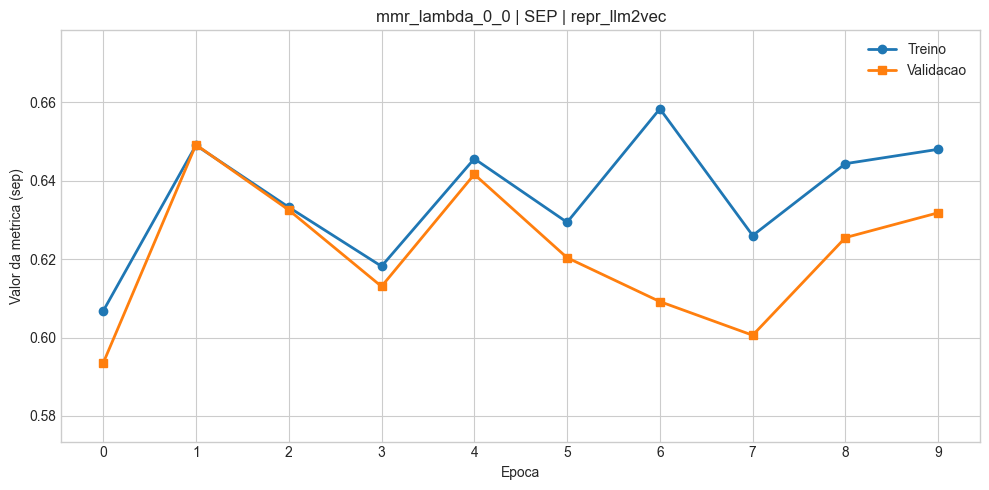

## Prompts por epoca no user_knn

### Epoca 0
- Status do prompt: baseline
- Train: 0.6067 (sem anterior)
- Validacao: 0.5935 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6490 (+0.0423)
- Validacao: 0.6491 (+0.0557)
- Refs MMR: epoca 0 (0.6067)
- Tamanho do prompt: 1324 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6332 (-0.0158)
- Validacao: 0.6325 (-0.0166)
- Refs MMR: epoca 1 (0.6490), epoca 0 (0.6067)
- Tamanho do prompt: 1032 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Explanation Attribute Prioritization**

Emphasize explanation pathways based upon detailed descriptions which convey notable relationships or substantial correlations between associated entities. Specifically rank such sequences as follows.

Preference Order for Explanation Paths:

1) Select those featuring characteristics which ensure optimal information richness, precision, and discriminability amongst choices – regardless of generalizability level.



Preferred explanations adhere strictly to well-defined interactional boundaries without unnecessary simplification at all times given the constraints of our guiding principles.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6182 (-0.0151)
- Validacao: 0.6130 (-0.0195)
- Refs MMR: epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0.6067)
- Tamanho do prompt: 998 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informative and Discernible Path Selection**
Optimize choice according to maximized explanation clarity. To achieve this, follow the prioritization protocol outlined below:

1 Prioritize paths with distinct attributes possessing highest specificity and descriptive power concerning interaction patterns.
2 In eventuality of comparable details, choose the description showcasing clearer linkages amidst related items over otherwise vague counterparts.
3 When tied with equal specificity, favor pathways encompassing direct or causal associations facilitating improved interpretation and enhanced comprehension.
```

...

Plotando rodada do user_knn: out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do user_knn
- Melhor treino: epoca 1 com valor 0.6490
- Melhor validacao: epoca 1 com valor 0.6491
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do user_knn
- Metrica de teste (SEP): 0.6876
- Delta vs without_optimization: +0.0619
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 237.16s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/user_knn/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do user_knn
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.606748,NaN,0.593477,NaN,nao,nao,691,sem refs MMR
1,1,0.649001,0.042252,0.649149,0.055672,sim,sim,1324,epoca 0 (0.6067)
2,2,0.633221,-0.015779,0.632508,-0.016641,sim,sim,1032,"epoca 1 (0.6490), epoca 0 (0.6067)"
3,3,0.618160,-0.015061,0.613024,-0.019484,sim,sim,998,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0..."
4,4,0.645580,0.027420,0.641596,0.028572,sim,sim,954,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
5,5,0.629368,-0.016212,0.620348,-0.021248,sim,sim,1155,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
6,6,0.639703,0.010335,0.640233,0.019885,sim,sim,996,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
7,7,0.622957,-0.016746,0.601531,-0.038702,sim,sim,985,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
8,8,0.644345,0.021389,0.625874,0.024343,sim,sim,1263,"epoca 1 (0.6490), epoca 6 (0.6397), epoca 0 (0..."
9,9,0.632718,-0.011627,0.646089,0.020215,sim,sim,1256,"epoca 1 (0.6490), epoca 6 (0.6397), epoca 0 (0..."


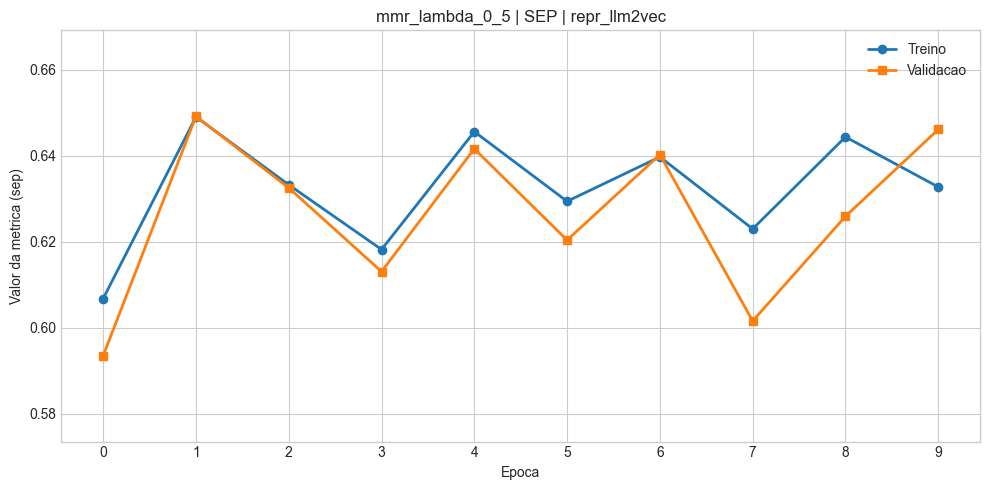

## Prompts por epoca no user_knn

### Epoca 0
- Status do prompt: baseline
- Train: 0.6067 (sem anterior)
- Validacao: 0.5935 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6490 (+0.0423)
- Validacao: 0.6491 (+0.0557)
- Refs MMR: epoca 0 (0.6067)
- Tamanho do prompt: 1324 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6332 (-0.0158)
- Validacao: 0.6325 (-0.0166)
- Refs MMR: epoca 1 (0.6490), epoca 0 (0.6067)
- Tamanho do prompt: 1032 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Explanation Attribute Prioritization**

Emphasize explanation pathways based upon detailed descriptions which convey notable relationships or substantial correlations between associated entities. Specifically rank such sequences as follows.

Preference Order for Explanation Paths:

1) Select those featuring characteristics which ensure optimal information richness, precision, and discriminability amongst choices – regardless of generalizability level.



Preferred explanations adhere strictly to well-defined interactional boundaries without unnecessary simplification at all times given the constraints of our guiding principles.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6182 (-0.0151)
- Validacao: 0.6130 (-0.0195)
- Refs MMR: epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0.6067)
- Tamanho do prompt: 998 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informative and Discernible Path Selection**
Optimize choice according to maximized explanation clarity. To achieve this, follow the prioritization protocol outlined below:

1 Prioritize paths with distinct attributes possessing highest specificity and descriptive power concerning interaction patterns.
2 In eventuality of comparable details, choose the description showcasing clearer linkages amidst related items over otherwise vague counterparts.
3 When tied with equal specificity, favor pathways encompassing direct or causal associations facilitating improved interpretation and enhanced comprehension.
```

...

Plotando rodada do user_knn: out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do user_knn
- Melhor treino: epoca 6 com valor 0.6528
- Melhor validacao: epoca 8 com valor 0.6649
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do user_knn
- Metrica de teste (SEP): 0.6721
- Delta vs without_optimization: +0.0464
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 235.88s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/user_knn/sep/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do user_knn
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.606748,NaN,0.593477,NaN,nao,nao,691,sem refs MMR
1,1,0.649001,0.042252,0.649149,0.055672,sim,sim,1324,epoca 0 (0.6067)
2,2,0.633221,-0.015779,0.632508,-0.016641,sim,sim,1032,"epoca 1 (0.6490), epoca 0 (0.6067)"
3,3,0.618160,-0.015061,0.613024,-0.019484,sim,sim,998,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0..."
4,4,0.650739,0.032579,0.651862,0.038838,sim,sim,1360,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 3 (0..."
5,5,0.622630,-0.028109,0.624857,-0.027005,sim,sim,1358,"epoca 4 (0.6507), epoca 1 (0.6490), epoca 3 (0..."
6,6,0.652782,0.030152,0.642130,0.017273,sim,sim,1345,"epoca 4 (0.6507), epoca 5 (0.6226), epoca 3 (0..."
7,7,0.643404,-0.009378,0.635157,-0.006974,sim,sim,1384,"epoca 6 (0.6528), epoca 1 (0.6490), epoca 5 (0..."
8,8,0.650050,0.006645,0.664871,0.029715,sim,sim,1238,"epoca 6 (0.6528), epoca 1 (0.6490), epoca 5 (0..."
9,9,0.639378,-0.010671,0.627495,-0.037376,sim,sim,1310,"epoca 6 (0.6528), epoca 1 (0.6490), epoca 5 (0..."


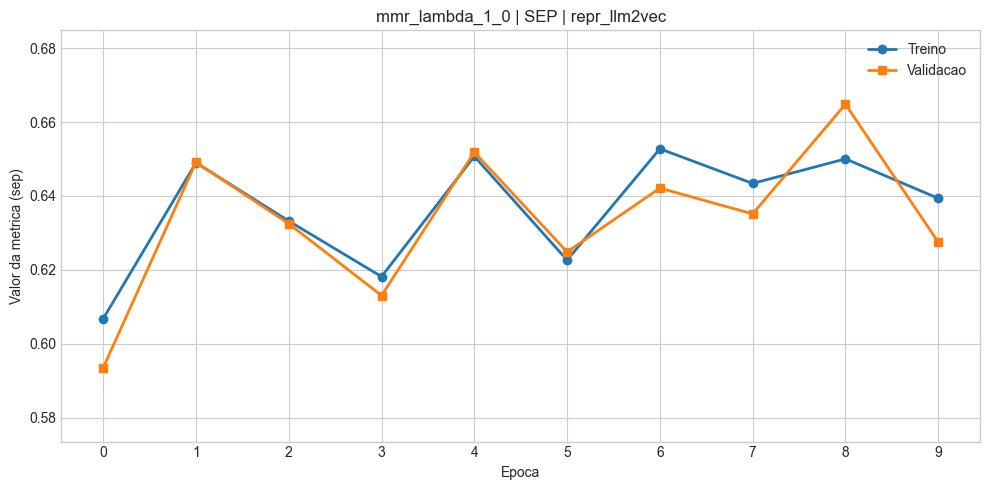

## Prompts por epoca no user_knn

### Epoca 0
- Status do prompt: baseline
- Train: 0.6067 (sem anterior)
- Validacao: 0.5935 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6490 (+0.0423)
- Validacao: 0.6491 (+0.0557)
- Refs MMR: epoca 0 (0.6067)
- Tamanho do prompt: 1324 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6332 (-0.0158)
- Validacao: 0.6325 (-0.0166)
- Refs MMR: epoca 1 (0.6490), epoca 0 (0.6067)
- Tamanho do prompt: 1032 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Explanation Attribute Prioritization**

Emphasize explanation pathways based upon detailed descriptions which convey notable relationships or substantial correlations between associated entities. Specifically rank such sequences as follows.

Preference Order for Explanation Paths:

1) Select those featuring characteristics which ensure optimal information richness, precision, and discriminability amongst choices – regardless of generalizability level.



Preferred explanations adhere strictly to well-defined interactional boundaries without unnecessary simplification at all times given the constraints of our guiding principles.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6182 (-0.0151)
- Validacao: 0.6130 (-0.0195)
- Refs MMR: epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0.6067)
- Tamanho do prompt: 998 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informative and Discernible Path Selection**
Optimize choice according to maximized explanation clarity. To achieve this, follow the prioritization protocol outlined below:

1 Prioritize paths with distinct attributes possessing highest specificity and descriptive power concerning interaction patterns.
2 In eventuality of comparable details, choose the description showcasing clearer linkages amidst related items over otherwise vague counterparts.
3 When tied with equal specificity, favor pathways encompassing direct or causal associations facilitating improved interpretation and enhanced comprehension.
```

...

Plotando rodada do user_knn: out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do user_knn
- Melhor treino: epoca 1 com valor 0.6490
- Melhor validacao: epoca 1 com valor 0.6491
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do user_knn
- Metrica de teste (SEP): 0.6876
- Delta vs without_optimization: +0.0619
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 236.70s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do user_knn
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.606748,NaN,0.593477,NaN,nao,nao,691,sem refs MMR
1,1,0.649001,0.042252,0.649149,0.055672,sim,sim,1324,epoca 0 (0.6067)
2,2,0.633221,-0.015779,0.632508,-0.016641,sim,sim,1032,"epoca 1 (0.6490), epoca 0 (0.6067)"
3,3,0.618160,-0.015061,0.613024,-0.019484,sim,sim,998,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0..."
4,4,0.645580,0.027420,0.641596,0.028572,sim,sim,954,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
5,5,0.629368,-0.016212,0.620348,-0.021248,sim,sim,1155,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
6,6,0.639703,0.010335,0.640233,0.019885,sim,sim,996,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
7,7,0.622957,-0.016746,0.601531,-0.038702,sim,sim,985,"epoca 1 (0.6490), epoca 3 (0.6182), epoca 0 (0..."
8,8,0.643158,0.020201,0.635440,0.033909,sim,sim,977,"epoca 1 (0.6490), epoca 7 (0.6230), epoca 0 (0..."
9,9,0.631397,-0.011761,0.622719,-0.012721,sim,sim,919,"epoca 1 (0.6490), epoca 8 (0.6432), epoca 0 (0..."


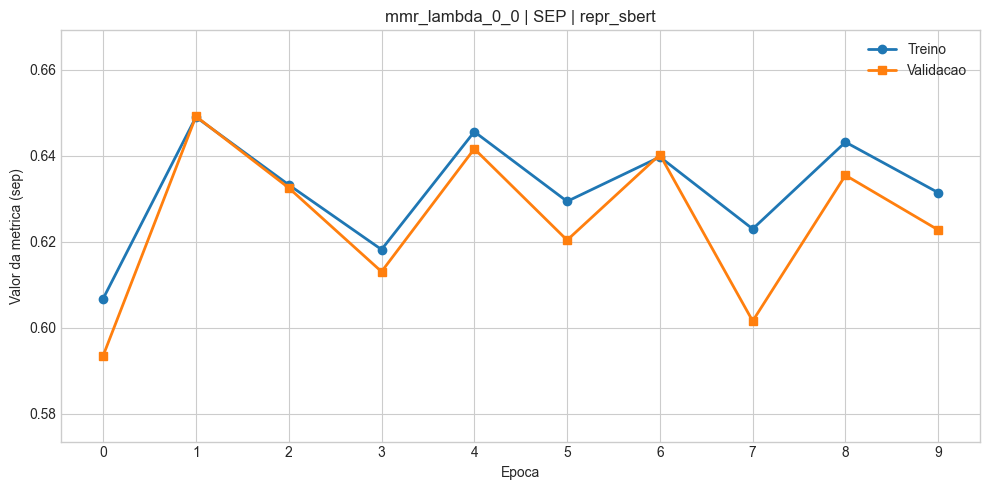

## Prompts por epoca no user_knn

### Epoca 0
- Status do prompt: baseline
- Train: 0.6067 (sem anterior)
- Validacao: 0.5935 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6490 (+0.0423)
- Validacao: 0.6491 (+0.0557)
- Refs MMR: epoca 0 (0.6067)
- Tamanho do prompt: 1324 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6332 (-0.0158)
- Validacao: 0.6325 (-0.0166)
- Refs MMR: epoca 1 (0.6490), epoca 0 (0.6067)
- Tamanho do prompt: 1032 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Explanation Attribute Prioritization**

Emphasize explanation pathways based upon detailed descriptions which convey notable relationships or substantial correlations between associated entities. Specifically rank such sequences as follows.

Preference Order for Explanation Paths:

1) Select those featuring characteristics which ensure optimal information richness, precision, and discriminability amongst choices – regardless of generalizability level.



Preferred explanations adhere strictly to well-defined interactional boundaries without unnecessary simplification at all times given the constraints of our guiding principles.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6182 (-0.0151)
- Validacao: 0.6130 (-0.0195)
- Refs MMR: epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0.6067)
- Tamanho do prompt: 998 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informative and Discernible Path Selection**
Optimize choice according to maximized explanation clarity. To achieve this, follow the prioritization protocol outlined below:

1 Prioritize paths with distinct attributes possessing highest specificity and descriptive power concerning interaction patterns.
2 In eventuality of comparable details, choose the description showcasing clearer linkages amidst related items over otherwise vague counterparts.
3 When tied with equal specificity, favor pathways encompassing direct or causal associations facilitating improved interpretation and enhanced comprehension.
```

...

Plotando rodada do user_knn: out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do user_knn
- Melhor treino: epoca 7 com valor 0.6520
- Melhor validacao: epoca 4 com valor 0.6519
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do user_knn
- Metrica de teste (SEP): 0.6734
- Delta vs without_optimization: +0.0477
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 234.52s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do user_knn
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.606748,NaN,0.593477,NaN,nao,nao,691,sem refs MMR
1,1,0.649001,0.042252,0.649149,0.055672,sim,sim,1324,epoca 0 (0.6067)
2,2,0.633221,-0.015779,0.632508,-0.016641,sim,sim,1032,"epoca 1 (0.6490), epoca 0 (0.6067)"
3,3,0.618160,-0.015061,0.613024,-0.019484,sim,sim,998,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0..."
4,4,0.650739,0.032579,0.651862,0.038838,sim,sim,1360,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 3 (0..."
5,5,0.622630,-0.028109,0.624857,-0.027005,sim,sim,1358,"epoca 4 (0.6507), epoca 1 (0.6490), epoca 3 (0..."
6,6,0.650443,0.027813,0.633340,0.008483,sim,sim,1092,"epoca 4 (0.6507), epoca 1 (0.6490), epoca 5 (0..."
7,7,0.652005,0.001562,0.651749,0.018408,sim,sim,1328,"epoca 4 (0.6507), epoca 1 (0.6490), epoca 5 (0..."
8,8,0.647519,-0.004487,0.645610,-0.006139,sim,sim,1398,"epoca 7 (0.6520), epoca 6 (0.6504), epoca 2 (0..."
9,9,0.646356,-0.001163,0.631496,-0.014114,sim,sim,1257,"epoca 7 (0.6520), epoca 6 (0.6504), epoca 2 (0..."


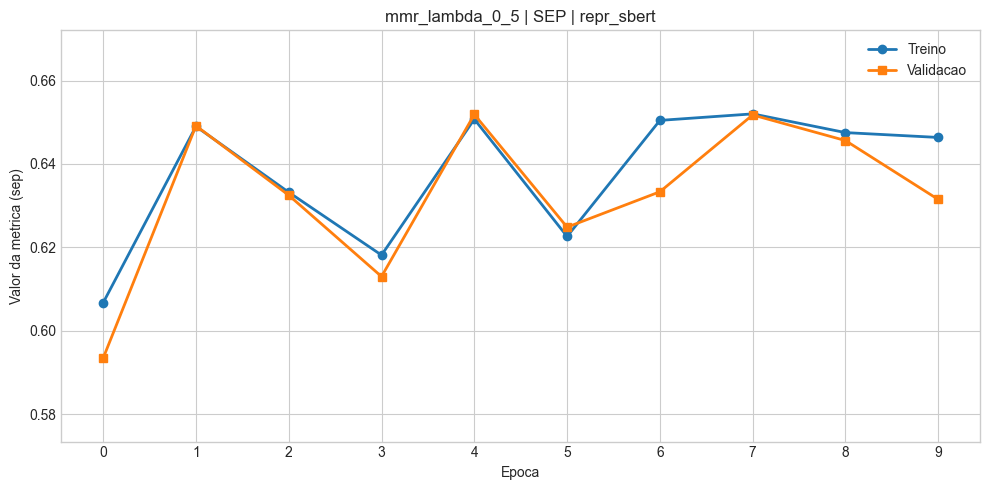

## Prompts por epoca no user_knn

### Epoca 0
- Status do prompt: baseline
- Train: 0.6067 (sem anterior)
- Validacao: 0.5935 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6490 (+0.0423)
- Validacao: 0.6491 (+0.0557)
- Refs MMR: epoca 0 (0.6067)
- Tamanho do prompt: 1324 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6332 (-0.0158)
- Validacao: 0.6325 (-0.0166)
- Refs MMR: epoca 1 (0.6490), epoca 0 (0.6067)
- Tamanho do prompt: 1032 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Explanation Attribute Prioritization**

Emphasize explanation pathways based upon detailed descriptions which convey notable relationships or substantial correlations between associated entities. Specifically rank such sequences as follows.

Preference Order for Explanation Paths:

1) Select those featuring characteristics which ensure optimal information richness, precision, and discriminability amongst choices – regardless of generalizability level.



Preferred explanations adhere strictly to well-defined interactional boundaries without unnecessary simplification at all times given the constraints of our guiding principles.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6182 (-0.0151)
- Validacao: 0.6130 (-0.0195)
- Refs MMR: epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0.6067)
- Tamanho do prompt: 998 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informative and Discernible Path Selection**
Optimize choice according to maximized explanation clarity. To achieve this, follow the prioritization protocol outlined below:

1 Prioritize paths with distinct attributes possessing highest specificity and descriptive power concerning interaction patterns.
2 In eventuality of comparable details, choose the description showcasing clearer linkages amidst related items over otherwise vague counterparts.
3 When tied with equal specificity, favor pathways encompassing direct or causal associations facilitating improved interpretation and enhanced comprehension.
```

...

Plotando rodada do user_knn: out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do user_knn
- Melhor treino: epoca 5 com valor 0.6549
- Melhor validacao: epoca 4 com valor 0.6519
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do user_knn
- Metrica de teste (SEP): 0.6774
- Delta vs without_optimization: +0.0517
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 242.30s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do user_knn
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.606748,NaN,0.593477,NaN,nao,nao,691,sem refs MMR
1,1,0.649001,0.042252,0.649149,0.055672,sim,sim,1324,epoca 0 (0.6067)
2,2,0.633221,-0.015779,0.632508,-0.016641,sim,sim,1032,"epoca 1 (0.6490), epoca 0 (0.6067)"
3,3,0.618160,-0.015061,0.613024,-0.019484,sim,sim,998,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0..."
4,4,0.650739,0.032579,0.651862,0.038838,sim,sim,1360,"epoca 1 (0.6490), epoca 2 (0.6332), epoca 3 (0..."
5,5,0.654928,0.004189,0.644723,-0.007139,sim,sim,1796,"epoca 4 (0.6507), epoca 1 (0.6490), epoca 2 (0..."
6,6,0.654359,-0.000569,0.647181,0.002458,sim,sim,1741,"epoca 5 (0.6549), epoca 4 (0.6507), epoca 1 (0..."
7,7,0.649584,-0.004775,0.647427,0.000245,sim,sim,2231,"epoca 5 (0.6549), epoca 6 (0.6544), epoca 1 (0..."
8,8,0.635852,-0.013733,0.640763,-0.006663,sim,sim,1709,"epoca 5 (0.6549), epoca 6 (0.6544), epoca 1 (0..."
9,9,0.652009,0.016157,0.618243,-0.022521,sim,sim,1764,"epoca 5 (0.6549), epoca 6 (0.6544), epoca 8 (0..."


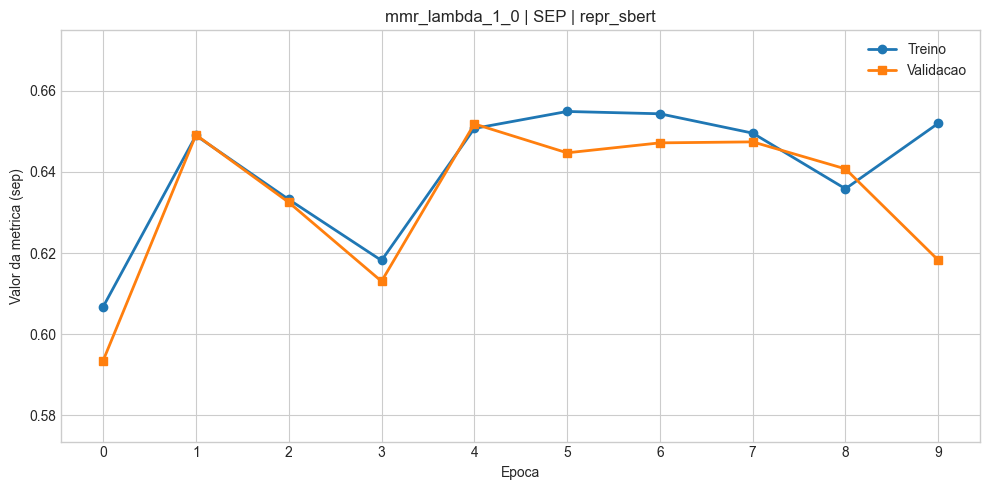

## Prompts por epoca no user_knn

### Epoca 0
- Status do prompt: baseline
- Train: 0.6067 (sem anterior)
- Validacao: 0.5935 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6490 (+0.0423)
- Validacao: 0.6491 (+0.0557)
- Refs MMR: epoca 0 (0.6067)
- Tamanho do prompt: 1324 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6332 (-0.0158)
- Validacao: 0.6325 (-0.0166)
- Refs MMR: epoca 1 (0.6490), epoca 0 (0.6067)
- Tamanho do prompt: 1032 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Explanation Attribute Prioritization**

Emphasize explanation pathways based upon detailed descriptions which convey notable relationships or substantial correlations between associated entities. Specifically rank such sequences as follows.

Preference Order for Explanation Paths:

1) Select those featuring characteristics which ensure optimal information richness, precision, and discriminability amongst choices – regardless of generalizability level.



Preferred explanations adhere strictly to well-defined interactional boundaries without unnecessary simplification at all times given the constraints of our guiding principles.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6182 (-0.0151)
- Validacao: 0.6130 (-0.0195)
- Refs MMR: epoca 1 (0.6490), epoca 2 (0.6332), epoca 0 (0.6067)
- Tamanho do prompt: 998 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informative and Discernible Path Selection**
Optimize choice according to maximized explanation clarity. To achieve this, follow the prioritization protocol outlined below:

1 Prioritize paths with distinct attributes possessing highest specificity and descriptive power concerning interaction patterns.
2 In eventuality of comparable details, choose the description showcasing clearer linkages amidst related items over otherwise vague counterparts.
3 When tied with equal specificity, favor pathways encompassing direct or causal associations facilitating improved interpretation and enhanced comprehension.
```

...

### repr_llm2vec | mmr_lambda_1_0 | mmr_pool_10
- Melhor epoca: 6
- Ganho da melhor epoca vs base no treino: +0.0460 (0.6067 -> 0.6528)
- Ganho da melhor epoca vs base na validacao: +0.0487 (0.5935 -> 0.6421)
- Teste sem otimizacao vs com melhor prompt: 0.6257 -> 0.6721 (+0.0464)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Structured Reasoning Selection

Optimize recommendation alignment through a stepwise assessment process based on explanation attribute distinctiveness. Follow this ranked evaluation framework to inform preferred pathway selections.

Ruling Criterion:

1 Ascribe higher value judgments to paths featuring intermediate attributes conferring enhanced discriminatory capabilities, distinguishing subtle variations between interacted and recommended objects.

2 Deem pathways as comparably valuable, but consider elevated above ambiguity-threshold ties those comprising transparent, straightforward inter-item connections – illuminating complex network topologies.

3 Whenever confronted with ambiguous attribution scenarios, favor paths encapsulating concrete cause-and-effect assertions or deductively-related sequences yielding richer, more interpretable understandings, even if less distinguishable along individual attributes than contemporaneous candidates.
```

### repr_sbert | mmr_lambda_0_0 | mmr_pool_10
- Melhor epoca: 1
- Ganho da melhor epoca vs base no treino: +0.0423 (0.6067 -> 0.6490)
- Ganho da melhor epoca vs base na validacao: +0.0557 (0.5935 -> 0.6491)
- Teste sem otimizacao vs com melhor prompt: 0.6257 -> 0.6876 (+0.0619)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

### repr_sbert | mmr_lambda_0_5 | mmr_pool_10
- Melhor epoca: 7
- Ganho da melhor epoca vs base no treino: +0.0453 (0.6067 -> 0.6520)
- Ganho da melhor epoca vs base na validacao: +0.0583 (0.5935 -> 0.6517)
- Teste sem otimizacao vs com melhor prompt: 0.6257 -> 0.6734 (+0.0477)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Strategic Path Prioritization

Prioritize pathways by leveraging three complementary criteria: 

Optimization Focus for Attribute Selection:

1. First, emphasize features offering exceptional detail enhancement over generic labels, especially if they unveil critical yet previously unknown connections between items.
   
2. Second, de-emphasize vague descriptor applications where more nuanced counterparts exist unless absolute necessity dictates otherwise due to equal description length.
   
3. Lastly, when competing attributes exhibit similar qualities in terms of information density, opt for intermediary components exhibiting obvious causal dependencies rather than abstract similarities, ensuring streamlined interpretation.

By employing this strategic approach to filtering explanations, ensure refined decision-making based on substantial linkages supporting the exploration rationale behind every preferred interaction sequence.
```

### repr_sbert | mmr_lambda_1_0 | mmr_pool_10
- Melhor epoca: 5
- Ganho da melhor epoca vs base no treino: +0.0482 (0.6067 -> 0.6549)
- Ganho da melhor epoca vs base na validacao: +0.0512 (0.5935 -> 0.6447)
- Teste sem otimizacao vs com melhor prompt: 0.6257 -> 0.6774 (+0.0517)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Guideline-Based Recommendation Selection**

Rationalizing explanations pathways for enhanced recommendation decisions involves optimizing preference according to structured evaluation processes based on detailed analysis. Implement prioritized pathway ordering accordingly through these rationalized decision-making guidelines.

1. Attribute Character Evaluation

   A. Assign high priority to detailed connections linking involved items, providing maximum clarity on correlations, and ensuring best-informed representation quality.
   
   B. If identical informativity levels apply, consider avoidances of broadly labeled representations.
   
   C. In similar detail scenarios yet varying specifics, opt for attributes manifesting crystal-clear contextual integration between successive elements within structured relations.

2. Specificity Overlap and Discriminatory Resolution Criteria

A. With equivalent specificity attained in pathways' connecting points, distinguish and choose higher distinctive structure qualities over common attributes.

B. Resolve further equivalencies utilizing comparative evaluations involving clearer relational patterns formed under constrained condition optimizations.


Guide implementation considering inherent trade-offs within these rules to derive informed recommendations rooted in comprehensive reasoning frameworks tailored towards nuanced resolution satisfaction.
```

### Comparacao final de teste
- Sem otimizacao: 0.6257 em SEP
- Tempo sem otimizacao: 223.49s
- Prompt sem otimizacao:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor resultado com otimizacao: 0.6876 em SEP
- Melhor configuracao no teste: mmr_lambda_0_5 | repr_llm2vec
- Tempo da melhor configuracao: 237.16s
- Ganho vs sem otimizacao: +0.0619
- Prompt da melhor configuracao no teste:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection**

Pursue the explanation path where its attribute is highly informative, provides unique insight into the relationship between interacted and recommended items, and offers maximal specificity and discriminativeness among options.

Prioritize:

1) Attributes conveying detailed connections or significant correlations between items.
   - These provide richer explanatory value compared to vague attributes.
   
2) Options avoiding too general labels even if equally detailed.
   - Ensure optimal discrimination in case of equivalent descriptions.
   
3) When comparable, select the attribute offering clearest structural relevance within the pathway. 
    This should logically reinforce the inter-item ties present throughout the sequence. 

Note:
Avoid overly simplistic labels and instead focus on discernible detail whenever achievable while still adhering closely to your defined explanations standards.
```

In [5]:
final_reports = []

if DEFAULT_TEST_RESULT is not None:
    display(Markdown(build_default_test_markdown(DEFAULT_TEST_RESULT)))

if catalog.empty:
    print(f"Nenhum arquivo optimization_process_metadata.json do user_knn foi encontrado em {DATA_DIR}.")
else:
    for metadata_path in catalog["optimization_metadata_path"]:
        print(f"Plotando rodada do user_knn: {metadata_path.relative_to(PROJECT_ROOT)}")
        plot_history(Path(metadata_path), save_figures=SAVE_FIGURES)

        payload, history, metric_name, lambda_name, pool_name = load_history(Path(metadata_path))
        history_table = build_history_table(history, metric_name, lambda_name, pool_name)
        test_result = find_test_result_for_metadata(Path(metadata_path), payload)
        final_reports.append(
            build_final_report_markdown(
                Path(metadata_path),
                payload,
                history_table,
                test_result,
                DEFAULT_TEST_RESULT,
            )
        )

    display(Markdown("## Relatório Final"))
    for report in final_reports:
        display(Markdown(report))
    display(Markdown(build_best_test_summary_markdown(DEFAULT_TEST_RESULT, with_opt_test_catalog)))

    if SAVE_FIGURES:
        print(f"Figuras do user_knn salvas em: {FIGURES_DIR}")
